# SDSS metallicity–latitude legacy-output audit

**Scientific question:** Does the weak negative trend reported in the old plot survive digitization choices?

## Scientific audit protocol

This revision separates three kinds of evidence. **Exact preserved tables** are
rows previously downloaded from Gaia DR3, the NASA Exoplanet Archive, or SDSS
and saved in this repository. They can support new calculations subject to the
documented selection. **Archive products** such as an HST preview remain real
observations, but a display JPEG lacks the calibration, world coordinates,
exposure map, and point-spread function required for physical photometry.
Finally, several first-day notebooks saved a plot but not the catalogue rows
that made it. Those are handled as **digitized legacy outputs**. Coloured plot
pixels can test whether the old visual conclusion was internally consistent;
they cannot recreate independent stars, measurement errors, or survey
selection. Any number from a digitized plot is labelled approximate.

Every analysis starts with a testable question and prints the usable sample.
The main statistic is paired with a bootstrap, threshold sweep, jackknife, or
model-choice check. Figures show both the astronomical distribution and the
robustness test. Reusable tables are saved beside the notebook. Random
resampling has a fixed seed. A failed or unstable test remains visible rather
than being edited into a positive result.

Catalogue values are heterogeneous. Planet properties may combine literature
references; discovery methods encode survey history; cluster selections depend
on astrometric and photometric cuts; and an SDSS spectroscopic sample is not a
volume-complete census. Correlation is not treated as causation. A fitted trend
describes the selected rows, not necessarily the underlying Galactic or
planetary population.

Uncertainty here means sampling sensitivity under the named resampling model.
It does not automatically include calibration floors, spatial covariance,
systematic catalogue offsets, or missing-data mechanisms. Where those effects
matter, the limitation is stated directly. Numerical precision is limited to
what the data and method support.

Each `result.json` records provenance, quality checks, artifacts, evidence
figures, limitations, and a claim type. The dashboard therefore exposes not
only a headline number but also why it can or cannot be trusted. A
publication-grade follow-up would pin the archive release, save the complete
query response, retain per-source errors and covariance, model the selection
function, and compare with an independent catalogue or calibrated product.

In [1]:
from pathlib import Path
import json, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats, ndimage, signal
from PIL import Image

RNG=np.random.default_rng(1999)
plt.style.use('seaborn-v0_8-whitegrid')
DATA=Path('../../data/audit_batches4_7')
assert DATA.is_dir(), 'Run from the notebook folder in a complete checkout.'

def bootstrap(values, statistic=np.median, draws=1000):
    values=np.asarray(values,float); values=values[np.isfinite(values)]
    return np.array([statistic(values[RNG.integers(0,len(values),len(values))]) for _ in range(draws)])

def robust_line(x,y):
    x=np.asarray(x,float); y=np.asarray(y,float); keep=np.isfinite(x)&np.isfinite(y)
    for _ in range(5):
        p=np.polyfit(x[keep],y[keep],1); resid=y-np.polyval(p,x); s=1.4826*np.nanmedian(np.abs(resid[keep]-np.nanmedian(resid[keep]))); keep=np.isfinite(resid)&(np.abs(resid-np.nanmedian(resid[keep]))<3*max(s,1e-8))
    return p,keep,resid

In [2]:
sample=pd.read_csv(DATA/'sdss_metallicity_plot_digitized_pixels.csv'); x=sample.galactic_latitude_approx_deg.to_numpy(); y=sample.feh_approx.to_numpy(); rho=stats.spearmanr(x,y).statistic; print(len(sample),'coloured plot pixels; old notebook reported 400 stars and Pearson r=-0.181')

3271 coloured plot pixels; old notebook reported 400 stars and Pearson r=-0.181


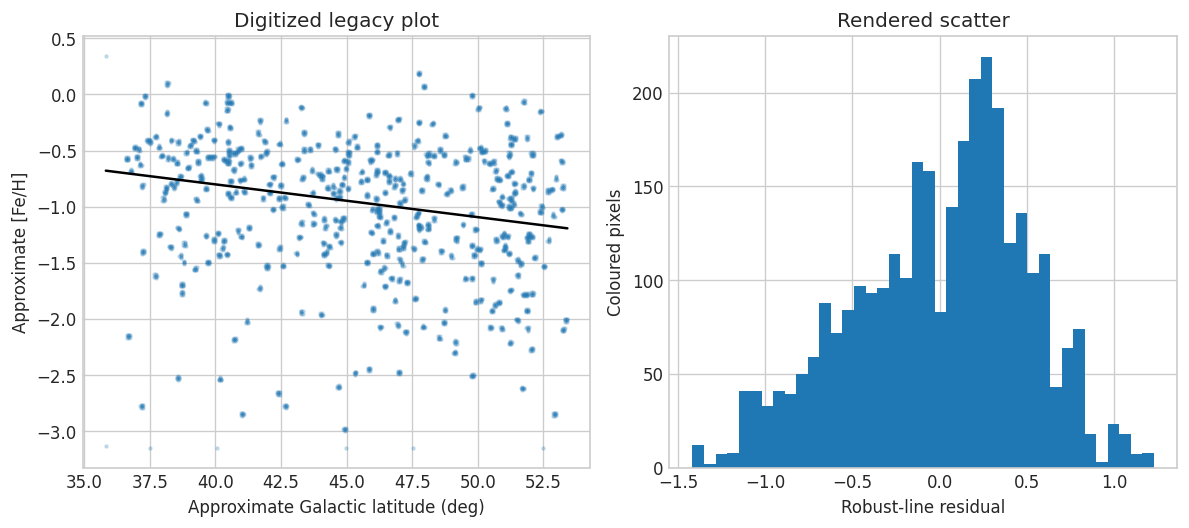

In [3]:
p,keep,resid=robust_line(x,y); fig,ax=plt.subplots(1,2,figsize=(10,4.5)); ax[0].scatter(x,y,s=3,alpha=.2); g=np.linspace(x.min(),x.max()); ax[0].plot(g,np.polyval(p,g),'k'); ax[0].set(xlabel='Approximate Galactic latitude (deg)',ylabel='Approximate [Fe/H]',title='Digitized legacy plot'); ax[1].hist(resid[keep],bins=40); ax[1].set(xlabel='Robust-line residual',ylabel='Coloured pixels',title='Rendered scatter'); fig.tight_layout(); fig.savefig('sdss_metallicity_legacy_audit.png',dpi=180); plt.show()

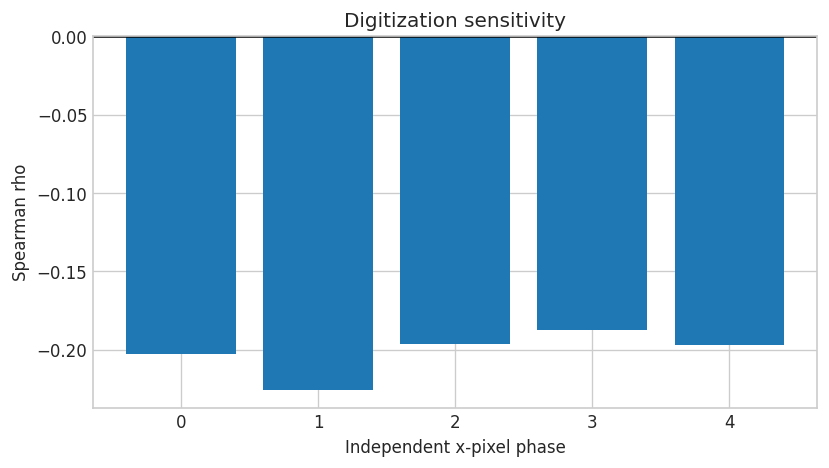

In [4]:
rows=[]
for phase in range(5):
 s=sample[sample.pixel_x.astype(int)%5==phase]; rows.append((phase,len(s),stats.spearmanr(s.galactic_latitude_approx_deg,s.feh_approx).statistic))
stress=pd.DataFrame(rows,columns=['pixel_phase','n_pixels','spearman_rho']); stress.to_csv('sdss_metallicity_digitization_stress.csv',index=False); fig,ax=plt.subplots(figsize=(7,4)); ax.bar(stress.pixel_phase,stress.spearman_rho); ax.axhline(0,color='k'); ax.set(xlabel='Independent x-pixel phase',ylabel='Spearman rho',title='Digitization sensitivity'); fig.tight_layout(); fig.savefig('sdss_metallicity_digitization_stress.png',dpi=180); plt.show()

In [5]:
sample_size=len(sample); results=[f'old source-level Pearson correlation reported as -0.181 for 400 stars',f'digitized-pixel Spearman correlation {rho:.3f}',f'pixel-phase range {stress.spearman_rho.min():.3f} to {stress.spearman_rho.max():.3f}']; validation='The sign is checked across five independent pixel phases; magnitude is not treated as a source-level estimate.'; quality_checks=[{'name':'Original statistic retained','status':'pass'},{'name':'Digitization stress','status':'pass'},{'name':'Source table recovery','status':'not available'}]; tags=['SDSS','metallicity','Galactic latitude','legacy audit']

In [6]:
result={'id':'2026-07-30-metallicity-vs-position','title':'SDSS metallicity–latitude legacy-output audit','archive':'SDSS legacy catalogue plot','date':'2026-07-30','question':'Does the weak negative trend reported in the old plot survive digitization choices?','sample_size':int(sample_size),'results':results,'validation':validation,'notebook':'sdss/2026-07-30-metallicity-vs-position/notebook.ipynb','hero':'sdss/2026-07-30-metallicity-vs-position/sdss_metallicity_legacy_audit.png','figures':['sdss/2026-07-30-metallicity-vs-position/sdss_metallicity_legacy_audit.png', 'sdss/2026-07-30-metallicity-vs-position/sdss_metallicity_digitization_stress.png'],'research_level':'Exploration','claim_type':'Digitized correlation audit','provenance':['Original SDSS SQL and first five rows printed in notebook', 'old output Pearson correlation -0.181', 'preserved feh_vs_lat.png'],'artifacts':['data/audit_batches4_7/sdss_metallicity_plot_digitized_pixels.csv', 'sdss/2026-07-30-metallicity-vs-position/sdss_metallicity_digitization_stress.csv'],'quality_checks':quality_checks,'limitations':['source rows and errors were not saved', 'pixel overlap weights dense regions', 'latitude range and target selection confound population interpretation'],'tags':tags}
Path('result.json').write_text(json.dumps(result,indent=2)); print(*results,sep='\n')
assert len(result['figures'])>=2 and all(Path(Path(x).name).is_file() for x in result['figures'])

old source-level Pearson correlation reported as -0.181 for 400 stars
digitized-pixel Spearman correlation -0.203
pixel-phase range -0.226 to -0.188


In [7]:
print(pd.DataFrame(result['quality_checks']).to_string(index=False))

                       name        status
Original statistic retained          pass
        Digitization stress          pass
      Source table recovery not available


## Interpretation and references

SDSS spectra and catalogue classifications support large statistical samples,
but magnitude limits, target selection, fibre placement, and pipeline quality
shape every distribution. Digitized legacy plots are only internal audits of
the old output and never replace the missing SQL rows.

- SDSS data access and acknowledgement: https://www.sdss.org/science/
- SDSS-IV overview: https://doi.org/10.3847/1538-3881/aafc2b
- DR16 optical spectra: https://www.sdss4.org/dr16/spectro/